# AUDIO ASSIGNMENT

# 1

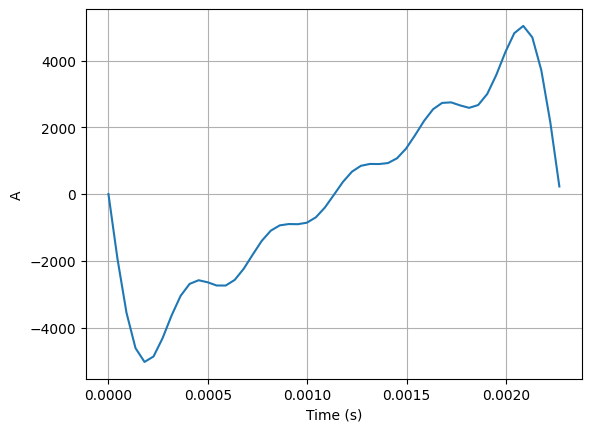

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do problema
# Aqui definimos a identidade da onda: amplitude, frequência
A = 5000
F = 440 
T = 1 / F
Fs = 22050

time = np.arange(0, T, 1 / Fs)

x = np.zeros(len(time))

for k in range(1,6):
    x += - (((2*A)/(np.pi * k)) * np.sin(2 * np.pi * F * k * time))

plt.figure()
plt.plot(time, x)
plt.title("")
plt.xlabel("Time (s)")
plt.ylabel("A")
plt.grid()
plt.show()

# 2

Function `geranota(nota, duracao, Fs)` that synthesises a musical note using the expression from equation (2.13) implemented in exercise 1, and applies fade-in/fade-out (1/10 of the total length at each end) using the first quarter-period of a sine.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def geranota(nota, duracao, Fs):
    # Period of the desired note.
    
    T0 = 1.0 / (440.0 * nota)
    A = 5000

    # Time vector for the full duration
    t = np.arange(0, duracao, 1.0 / Fs)
    amostras = np.zeros(len(t))

    # Waveform synthesis using the first 5 terms of the summation
    
    F = 1.0 / T0
    for k in range(1, 6):
        amostras += -(2.0 * A / (np.pi * k)) * np.sin(2.0 * np.pi * k * F * t)

    # Fade-in and fade-out using the first quarter-period of a sine:
    # smooth ramp 0 -> 1 over the first 1/10, and 1 -> 0 over the last 1/10.
    N = len(amostras)
    L = N // 10
    if L > 0:
        ramp = np.sin(np.linspace(0, np.pi / 2, L))
        amostras[:L]  *= ramp        
        amostras[-L:] *= ramp[::-1]  

    return amostras


### Testing the function

Generating an LA4 note (`nota = 1.0`) with 500 ms duration to visualise the fade-in and fade-out effect.

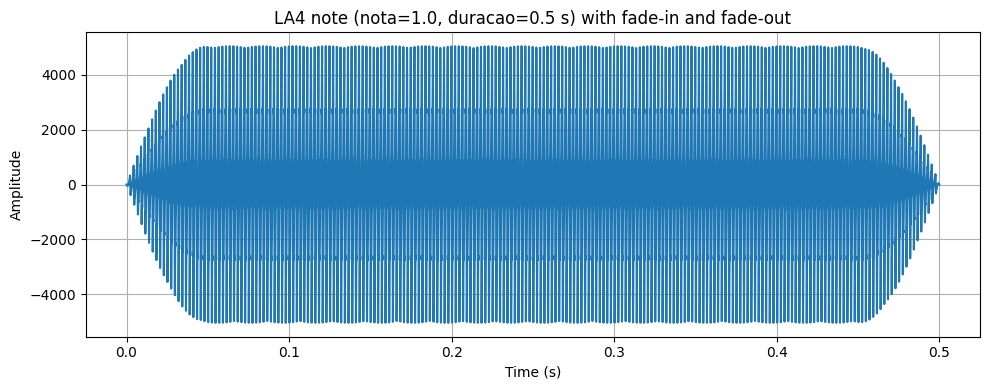

In [ ]:
Fs = 22050
y = geranota(1.0, 0.5, Fs)

t_axis = np.arange(len(y)) / Fs

plt.figure(figsize=(10, 4))
plt.plot(t_axis, y)
plt.title("LA4 note (nota=1.0, duracao=0.5 s) with fade-in and fade-out")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.tight_layout()
plt.show()
